# RobStatTM-Py, UI walk-through

Live demonstration of the user-facing surface promised by `docs/user_interface.md`.
Each cell is an independent step; nothing here is mocked, every fit is a real R call via `rpy2`.

**TL;DR for a new user:**
```python
import robstattm_py as rpm
df  = rpm.datasets.mineral()
fit = rpm.lmrobdet_mm("zinc ~ copper", data=df)
print(fit.summary())
```

## 0. Environment bootstrap (Windows only, sets R_HOME so rpy2 finds R)

In [1]:
import os, sys

import robstattm_py as rpm
print('robstattm_py', rpm.__version__)
print('public symbols on package root:',
      len([n for n in dir(rpm) if not n.startswith('_')]))

robstattm_py 0.0.1.dev0
public symbols on package root: 59


## 1. `check_setup()`, environment report

In [2]:
rpm.check_setup();

RobStatTM-Py setup check
Python:       3.14.3
robstattm_py:  0.0.1.dev0
rpy2:         unknown
R:            R version 4.5.2 (2025-10-31 ucrt)
  RobStatTM     1.0.11                          ✓
  robustbase    0.99.7                          ✓
  rrcov         1.7.7                           ✓
  pyinit        1.1.5                           ✓
  pense         (not installed)  stretch wrappers unavailable  ⚠
  GSE           (not installed)  stretch wrappers unavailable  ⚠

Optional stretch packages, run in R if you want them:
  install.packages(c('pense', 'GSE'))

Result: READY for core wrappers. STRETCH WRAPPERS UNAVAILABLE.


## 2. Datasets, pandas DataFrames with R column names
20 textbook datasets, exposed as functions:

In [3]:
import pandas as pd
df = rpm.datasets.mineral()
print('shape:', df.shape)
df.head()

shape: (53, 2)


,copper,zinc
1,102.0,4.0
2,96.0,56.0
3,265.0,2.0
4,185.0,8.0
5,229.0,26.0


## 3. Fit a robust regression
`lmrobdet_mm` accepts an R-style formula string + a pandas DataFrame. The result
object has a useful `__repr__`:

In [4]:
fit = rpm.lmrobdet_mm('zinc ~ copper', data=df)
fit

R callback write-console: Registered S3 method overwritten by 'robustbase':
  method          from     
  hatvalues.lmrob RobStatTM
  


<LmrobdetMMResult: zinc ~ copper | (Intercept)=15.2, copper=0.01256 | scale=9.997, R²=0.008, iter=17, converged=True>

## 4. `.summary()`, same print as R's `summary(lmrobdetMM(...))`

In [5]:
print(fit.summary())

Call: lmrobdetMM-family(zinc ~ copper)

Coefficients:
             Estimate  Std. Error  t value   Pr(>|t|)
(Intercept)    15.201      2.2532   6.7465 1.3686e-08
copper       0.012561    0.022269  0.56408    0.57517

Robust residual standard error: 9.997
Multiple R-squared: 0.008201, Adjusted R-squared: -0.01125
Convergence in 17 IRWLS iterations


## 5. `.summary().coefficients_table`, pandas, ready for downstream work

In [6]:
fit.summary().coefficients_table

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),15.201217,2.253191,6.746528,1.368631e-08
copper,0.012561,0.022269,0.564082,5.751705e-01


## 6. `.predict(newdata)`, accepts pandas DataFrames

In [7]:
new_df = pd.DataFrame({'copper': [10, 50, 100, 500]})
pd.DataFrame({'copper': new_df['copper'], 'zinc_pred': fit.predict(new_df)})

,copper,zinc_pred
0,10,15.326832
1,50,15.829292
2,100,16.457367
3,500,21.481965


## 7. `.hatvalues()`, manual reimplementation of `hatvalues.lmrob`
Sanity check: trace of the hat matrix should equal the number of predictors ($p = 2$ here).

In [8]:
hv = fit.hatvalues()
print(f'hatvalues range: [{hv.min():.4f}, {hv.max():.4f}]')
print(f'sum of hatvalues: {hv.sum():.6f}  (== p = 2)')

hatvalues range: [0.0000, 0.1837]
sum of hatvalues: 2.000000  (== p = 2)


## 8. Covariance, `cov_rob_mm` + `.summary()`

In [9]:
import numpy as np
wine = rpm.datasets.wine()
rpm.set_seed(42)
cov_fit = rpm.cov_rob_mm(wine)
print(repr(cov_fit))
csum = cov_fit.summary()
print('first 5 eigenvalues       :', np.round(csum.evals[:5], 4))
print('first 5 proportion of var :', np.round(csum.proportion_of_variance[:5], 4))

<CovRobMMResult: n=59 p=13 mean_weight=0.136>
first 5 eigenvalues       : [4.885841e+04 1.170145e+02 6.500100e+00 1.138600e+00 2.050000e-01]
first 5 proportion of var : [9.974e-01 2.400e-03 1.000e-04 0.000e+00 0.000e+00]


## 9. Robust PCA, `prcomp_rob`

In [10]:
rpm.set_seed(42)
prc = rpm.prcomp_rob(wine)
print(repr(prc))
prc.summary().importance.iloc[:, :5]

<PrcompRobResult: q=13, sdev=[221.527  10.429   2.497]...>


,PC 1,PC 2,PC 3,PC 4,PC 5
Standard deviation,221.526668,10.428932,2.497379,0.973982,0.644517
Proportion of Variance,0.997620,0.002210,0.000130,0.000020,0.000010
Cumulative Proportion,0.997620,0.999830,0.999960,0.999980,0.999990


## 10. Robust logistic regression, `by_logreg`

In [11]:
np.random.seed(0)
x = np.random.randn(60)
y = (x + 0.5 * np.random.randn(60) > 0).astype(int)
logfit = rpm.by_logreg(X=x[:, None], y=y)
print('coefficients:', logfit.coefficients)
print('converged   :', logfit.converged)

coefficients: [0.33627146 3.35943968]
converged   : True


## 11. Plotting, Path A (direct R-graphics PNG via rpy2)
`rpm.plotting.r_plot()` runs arbitrary R plotting code and returns a PNG path that the notebook displays inline.

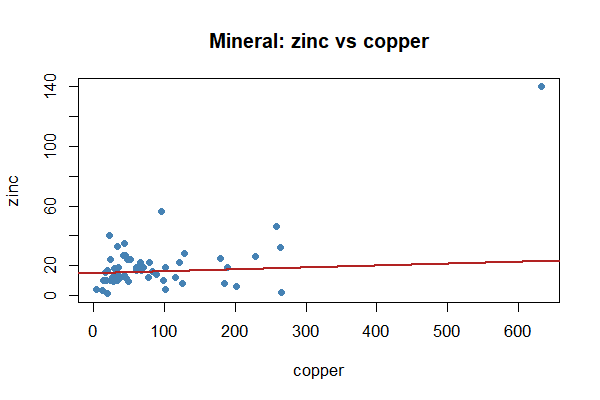

In [12]:
from robstattm_py.plotting import r_plot, show_png
fig = r_plot(
    """
    plot(zinc ~ copper, data=mineral, pch=19, col='steelblue',
         main='Mineral: zinc vs copper')
    abline(lmrobdetMM(zinc ~ copper, data=mineral), col='firebrick', lwd=2)
    """,
    path='figures/ui_demo_scatter.png', dpi=100, width=6, height=4,
)
show_png(fig)

## 12. Round-trip: result objects are pickle-safe

In [13]:
import pickle
back = pickle.loads(pickle.dumps(fit))
print('round-trip coefficients :', back.coefficients)
print('round-trip scale         :', back.summary().scale)

round-trip coefficients : [1.52012174e+01 1.25614958e-02]
round-trip scale         : 9.996566341639118


## 13. R-name alias layer (`robstattm_py.compat_r`)
For users transcribing code from Maronna et al. (2019), keep the original R names verbatim:

In [14]:
from robstattm_py.compat_r import lmrobdetMM, covRobMM, BYlogreg, data
mineral = data('mineral')
alias_fit = lmrobdetMM('zinc ~ copper', data=mineral)
import numpy as np
print('same callable :', lmrobdetMM is rpm.lmrobdet_mm)
print('same answer   :', np.array_equal(alias_fit.coefficients, fit.coefficients))

same callable : True
same answer   : True


---
## Summary

| Surface | Status |
|---|---|
| `rpm.check_setup()` | works, Windows-safe |
| `rpm.datasets.<name>()` | pandas DataFrames |
| `rpm.lmrobdet_mm` + `__repr__` / `summary()` / `predict()` / `hatvalues()` | works |
| `rpm.cov_rob_mm` + `.summary()` | works (eigenvalues, prop variance) |
| `rpm.prcomp_rob` + `.summary().importance` | works (pandas) |
| `rpm.by_logreg` | works |
| `rpm.plotting.r_plot()` (Path A) | works, pixel-perfect R graphics |
| Pickle round-trip | works |
| `compat_r` (R-name aliases) | works |